# Gradient Descent and Variants on 3D Functions

This notebook should implement and demonstrate:
- Gradient Descent (GD)
- Newton's Method (with optimal step-size with Hessian + damping)
- AdaGrad
- Adam

on three 3D objective functions with **visualized optimization trajectories**.

**This notebook is designed to give you a starting point for the assignment. However you are free to make changes as you wish.**

# Setup

In [ ]:
import math, sys, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy.typing import NDArray
import time
from typing import Callable

# Reproducibility (if you do any random generation)
np.random.seed(123)

# You can change this is if you wish
plt.rcParams.update({
    "figure.figsize": (6,5),
    "axes.grid": False
})

# Objective Functions, Gradients, and Hessians


## Option 1 - Manual

In [ ]:
def f1(xy: tuple[float, float]) -> float:
    x, y = xy
    return x**2 + y**2

def f1_grad(xy: tuple[float, float]) -> NDArray:
    x, y = xy
    return np.array([2*x, 2*y], dtype=float)


functions = {
    "f1": (f1, f1_grad),
}

print(f1((1.0, 2.0)))
print(f1_grad((1.0, 2.0)))

5.0
[2. 4.]


### Hessian (For Newton's Method)

In [ ]:
import scipy

x0 = (1.0, 2.0)
hessian = scipy.differentiate.hessian(f1, x0).ddf
h_inv = np.linalg.inv(hessian)
h_inv

array([[ 5.00000000e-01,  7.10542736e-15],
       [-1.53943407e-13,  5.00000000e-01]])

In [ ]:
grad = f1_grad((1.0, 2.0))
x_next = x0 - h_inv @ grad
x_next

array([-2.72670775e-13, -8.74855743e-14])

## Option 2 - PyTorch

If you don't want to evaluate the gradient function by hand, you can use a number of autograd packages (PyTorch, JAX, etc.). PyTorch is shown here.

In [ ]:
import torch

def f1_torch(x: torch.Tensor) -> torch.Tensor:
    return torch.sum(x**2)

x = torch.tensor([1.0, 2.0])
y = f1_torch(x)
# torch.func.grad returns the gradient function of whatever function you provide it with
f1_torch_grad = torch.func.grad(f1_torch)
f1_torch_grad(x)

tensor([2., 4.])

### Hessian (For Newton's Method)

In [ ]:
x0 = torch.tensor([1.0, 2.0])
hessian = torch.autograd.functional.hessian(f1_torch, x0)
h_inv = torch.linalg.inv(hessian)
h_inv

tensor([[0.5000, 0.0000],
        [0.0000, 0.5000]])

In [ ]:
grad = f1_torch_grad(x0)
x_next = x0 - h_inv @ grad
x_next

tensor([0., 0.], grad_fn=<SubBackward0>)



```
`# This is formatted as code`
```

# Optimizers

## Gradient Descent

### Option 1 - Manual

In [ ]:
def gradient_descent(
        step_size: float,
        grad_fn:   Callable,
        x0:        tuple[float, float],
        max_iters: int = 2000,
        tol:       float = 1e-6
    ) -> NDArray:

    x = np.array(x0, dtype=float)
    path = [x.copy()]
    for k in range(max_iters):
        grad = grad_fn(x)
        x_next = x - step_size * grad
        path.append(x_next.copy())
        # If x has barely changed since the last iteration, we have converged
        if np.linalg.norm(x_next - x) < tol:
            break
        x = x_next
    return np.array(path)

gradient_descent(0.1, f1_grad, (1.0, 2.0))[-1]

array([1.53249554e-06, 3.06499108e-06])

### Option 2 - PyTorch

Note the very small differences here. Mainly with method naming.

In [ ]:
def gradient_descent_torch(
        step_size: float,
        grad_fn:   Callable,
        x0:        tuple[float, float],
        max_iters: int = 2000,
        tol:       float = 1e-6
    ) -> NDArray:
    x = torch.tensor(x0, dtype=float)
    path = [x.clone()]
    for _ in range(max_iters):
        grad = grad_fn(x)
        x_next = x - step_size * grad
        path.append(x_next.clone())
        # If x has barely changed since the last iteration, we have converged
        if torch.linalg.norm(x_next - x) < tol:
            break
        x = x_next
    return np.array(path)

gradient_descent_torch(0.1, f1_torch_grad, (1.0, 2.0))[-1]

array([1.53249554e-06, 3.06499108e-06])

# Visualization

## Visualization Utility

In [ ]:
def plot_contours_with_path(
        f:      Callable,
        path:   str,
        xlim:   tuple[int, int] = (-3,3),
        ylim:   tuple[int, int] = (-3,3),
        levels: int = 40,
        title:  str = ""
    ):
    xs = np.linspace(xlim[0], xlim[1], 400)
    ys = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(xs, ys)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f((X[i, j], Y[i, j]))
    plt.figure()
    cs = plt.contour(X, Y, Z, levels=levels)
    plt.clabel(cs, inline=1, fontsize=8)
    P = np.asarray(path)
    plt.plot(P[:,0], P[:,1], marker='o', linewidth=1)
    plt.title(title)
    plt.xlabel('x'); plt.ylabel('y')
    plt.show()

## Function f1 (Quadratic)

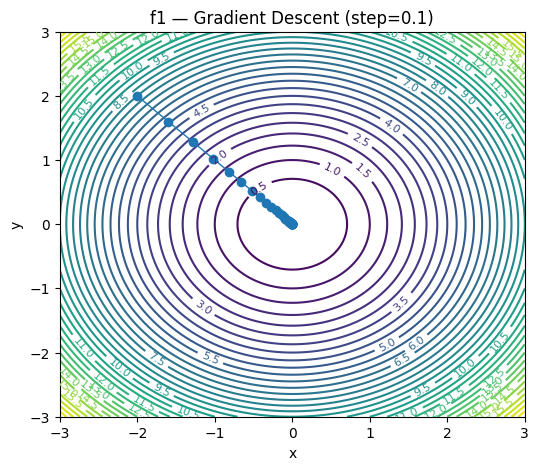

In [ ]:
# GD
f, g = functions["f1"]
path = gradient_descent(0.1, g, (-2.0, 2.0))
plot_contours_with_path(f1, path, title="f1 — Gradient Descent (step=0.1)", levels=40)

# Parameter Sensitivity & Comparative Results

We sweep multiple step sizes and initializations, then summarize final objective values and iterations.


In [ ]:
def run_experiment(
        func_key:       str,
        x0:             tuple[float, float],
        optimizer_name: str,
        step:           float,
        **kwargs
    ):
    f, g = functions[func_key]
    if optimizer_name == "GD":
        start = time.perf_counter()
        path = gradient_descent(step, g, x0, **kwargs)
        time_elapsed = time.perf_counter() - start
    # elif optimizer_name == "some other thing":
    # ...
    else:
        raise ValueError("Unknown optimizer")
    return {
        "function": func_key,
        "optimizer": optimizer_name,
        "start": start,
        "step": step,
        "iters": len(path)-1,
        "time": time_elapsed,
        "final_x": path[-1][0],
        "final_y": path[-1][1],
        "final_f": f(path[-1])
    }

tests = []

parameter_grid = {
    "GD": {
        "starting_points": [(-2.0, 2.0), (0.5, -1.5), (3.0, 3.0)],
        "steps": [0.001, 0.01, 0.1]
        }
}


for func_key in functions.keys():
    for variant_key, parameter_dict in parameter_grid.items():
            for x0 in parameter_dict["starting_points"]:
                for step_size in parameter_dict["steps"]:
                    tests.append(run_experiment(func_key, x0, variant_key, step_size, max_iters=1000, tol=1e-6))

df = pd.DataFrame(tests)
df.sort_values(["function","optimizer","final_f"], inplace=True)
df.reset_index(drop=True, inplace=True)
df.head(10)

,function,optimizer,start,step,iters,time,final_x,final_y,final_f
0,f1,GD,12995.624324,0.100,63,0.000561,0.000002,0.000002,1.108181e-11
1,f1,GD,12995.594829,0.100,61,0.000571,-0.000002,0.000002,1.202454e-11
2,f1,GD,12995.609381,0.100,58,0.000533,0.000001,-0.000004,1.433437e-11
3,f1,GD,12995.589758,0.010,543,0.005056,-0.000034,0.000034,2.369235e-09
4,f1,GD,12995.619204,0.010,563,0.005111,0.000034,0.000034,2.375931e-09
5,f1,GD,12995.604813,0.010,514,0.004552,0.000015,-0.000046,2.389713e-09
6,f1,GD,12995.595407,0.001,1000,0.009389,0.067532,-0.202597,4.560606e-02
7,f1,GD,12995.577617,0.001,1000,0.012114,-0.270129,0.270129,1.459394e-01
8,f1,GD,12995.609921,0.001,1000,0.009267,0.405194,0.405194,3.283637e-01


Do any further analysis and comparison below. What do you notice between the methods? Discuss how many iterations they take based on parameter choices, the time, etc.